In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import pickle


In [40]:
!pip install -q xgboost lightgbm imbalanced-learn

In [41]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.shape


(7043, 21)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [45]:
hidden_nulls = (df['TotalCharges'] == " ") | (df['TotalCharges'] == "")
print(f"Number of hidden missing values (blank spaces) in TotalCharges: {hidden_nulls.sum()}")


Number of hidden missing values (blank spaces) in TotalCharges: 11


In [46]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges count:", df['TotalCharges'].isnull().sum())

total_charges_median = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(total_charges_median)

print("\nRemaining Missing Values in Dataset:")
print(df.isnull().sum().sum())


Missing TotalCharges count: 11

Remaining Missing Values in Dataset:
0


In [47]:
df.drop('customerID', axis=1, inplace=True)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [49]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

outliers_count = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count[col] = len(outliers)

print("Number of Outliers found per column using IQR:")
for col, count in outliers_count.items():
    print(f"- {col}: {count} outliers")

if sum(outliers_count.values()) == 0:
    print("\nNo outliers detected in any numerical column — no outlier treatment needed.")


Number of Outliers found per column using IQR:
- tenure: 0 outliers
- MonthlyCharges: 0 outliers
- TotalCharges: 0 outliers

No outliers detected in any numerical column — no outlier treatment needed.


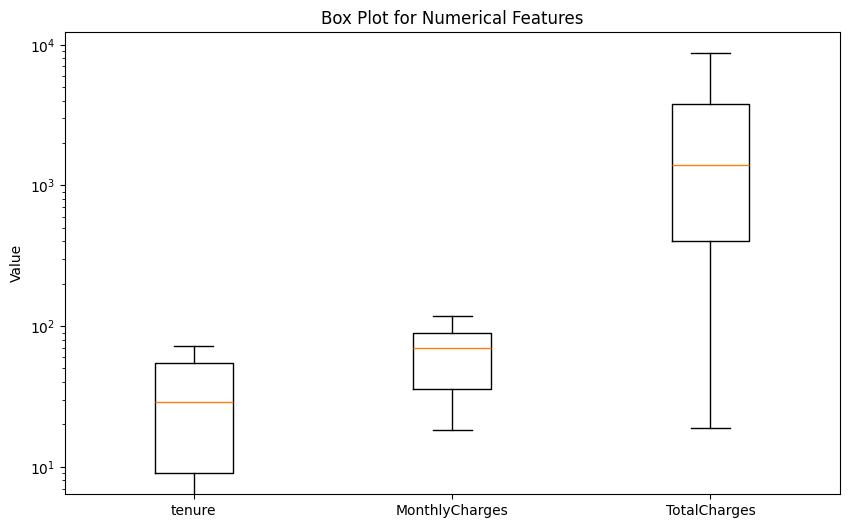

In [50]:
plt.figure(figsize=(10, 6))
plt.boxplot(df[num_cols].values, labels=num_cols)
plt.yscale('log')
plt.title("Box Plot for Numerical Features")
plt.ylabel("Value")
plt.show()


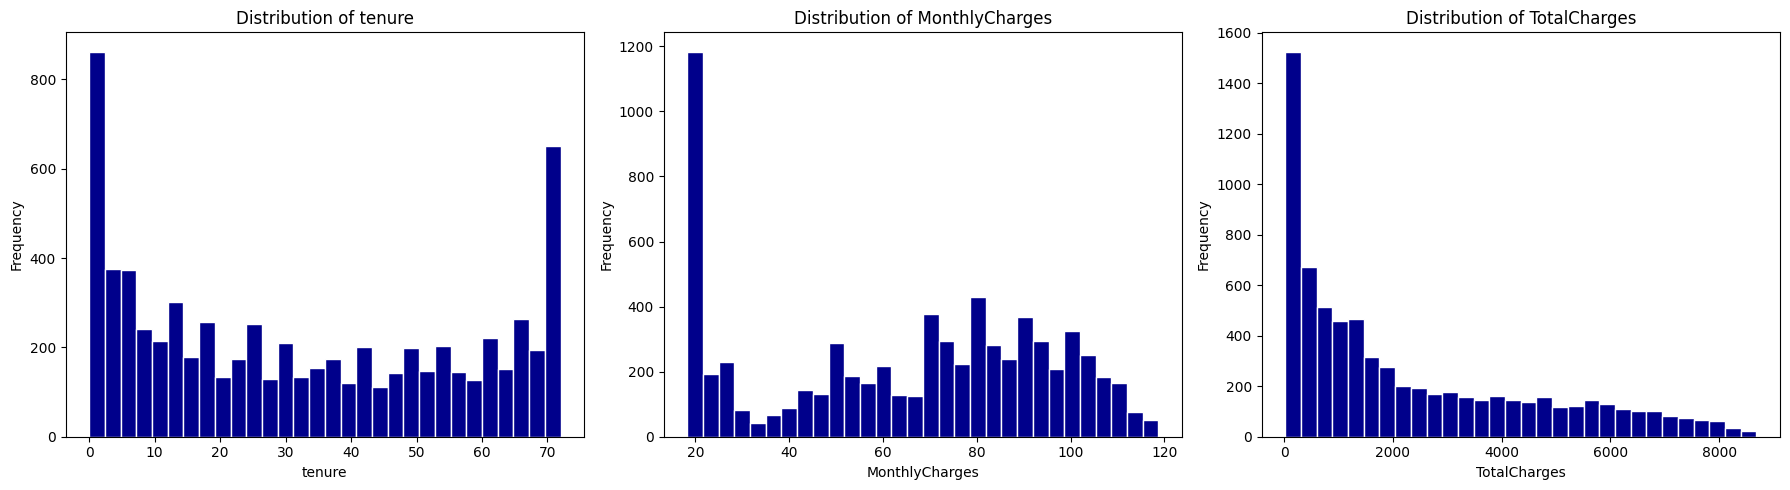

In [51]:
# Distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='darkblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


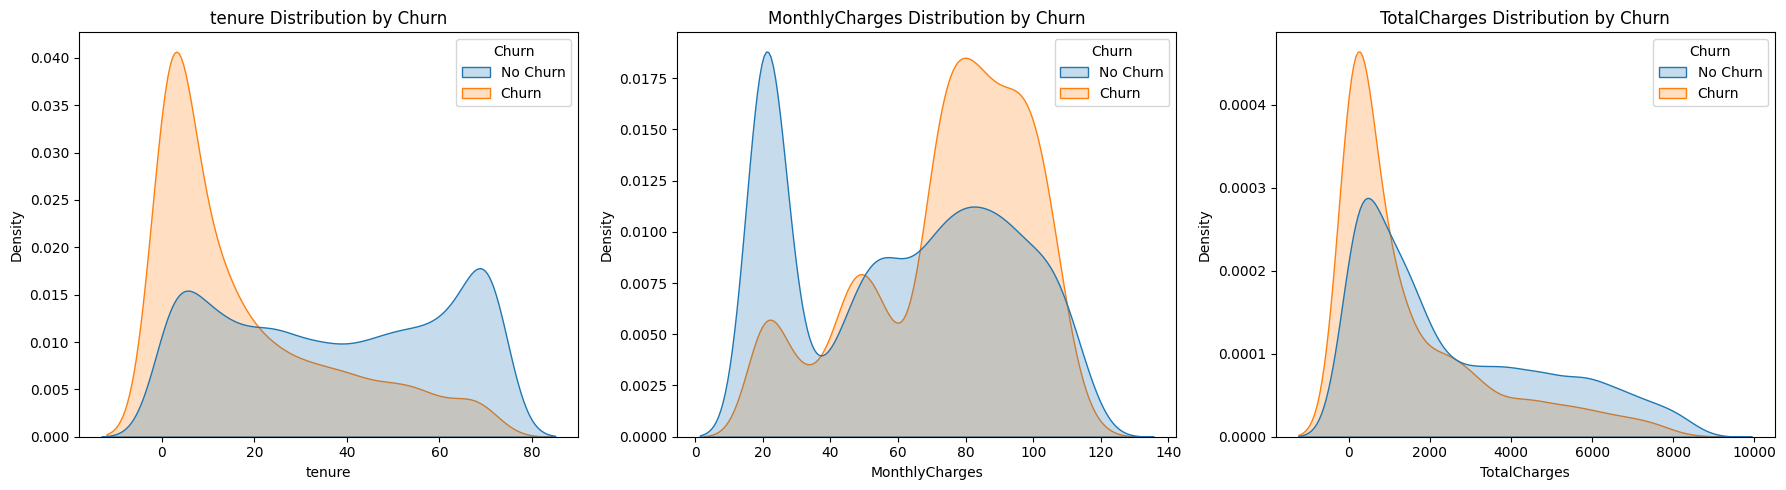

In [52]:
# Effect of each numerical feature on churn
churn_labels = df['Churn'].map({'Yes': 'Churn', 'No': 'No Churn'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df.assign(Churn=churn_labels), x=col, hue='Churn',
                fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Churn')
plt.tight_layout()
plt.show()


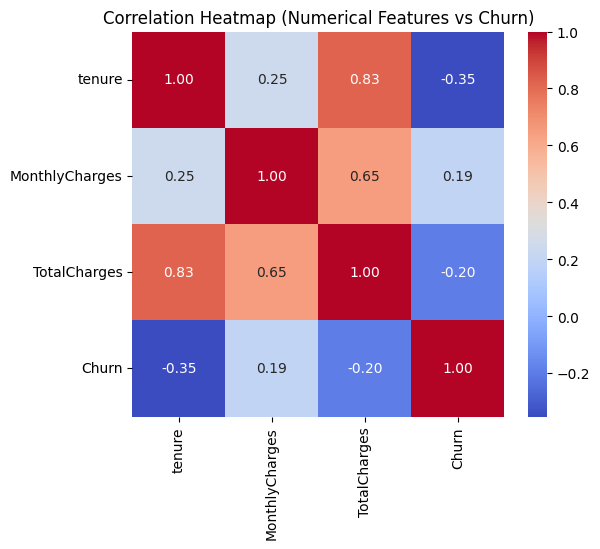

In [53]:
# Correlation heatmap for numerical features (incl. target)
corr_df = df[num_cols].copy()
corr_df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap (Numerical Features vs Churn)")
plt.show()


In [54]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

print("Shape of dataset before encoding:", df.shape)
print("Shape of dataset after encoding:", df_encoded.shape)
df = df_encoded
df.head()


Shape of dataset before encoding: (7043, 20)
Shape of dataset after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [55]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)


(5634, 30)
(1409, 30)


In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [58]:
results = []

def evaluate_model(name, model, X_train, y_train, X_test, y_test, results_list=results, plot_cm=False):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    if plot_cm:
        plt.figure(figsize=(4, 3.5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
        plt.title(f'{name} — Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

    results_list.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1, "ROC-AUC": roc_auc, "y_proba": y_proba
    })
    return model


In [59]:
log_reg = LogisticRegression()
log_reg = evaluate_model("Logistic Regression", log_reg, X_train_scaled, y_train, X_test_scaled, y_test)



===== Logistic Regression =====
Accuracy : 80.70%
Precision: 0.6584
Recall   : 0.5668
F1-Score : 0.6092
ROC-AUC  : 0.8416
Confusion Matrix:
 [[925 110]
 [162 212]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [60]:
intercept = log_reg.intercept_[0]
coefficients = log_reg.coef_[0]
print(f"Model Intercept (b): {intercept:.4f}\n")

weights_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight (w)': coefficients
}).sort_values(by='Weight (w)', ascending=False)

print("Top Features influencing Churn (Logistic Regression Weights):")
display(weights_df.head(5))
display(weights_df.tail(5))


Model Intercept (b): -1.7024

Top Features influencing Churn (Logistic Regression Weights):


,Feature,Weight (w)
10,InternetService_Fiber optic,0.778760
3,TotalCharges,0.497246
23,StreamingMovies_Yes,0.258653
21,StreamingTV_Yes,0.258042
9,MultipleLines_Yes,0.216356


,Feature,Weight (w)
13,OnlineSecurity_Yes,-0.123430
24,Contract_One year,-0.286473
25,Contract_Two year,-0.588975
2,MonthlyCharges,-0.921369
1,tenure,-1.219639


In [61]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model = evaluate_model("Decision Tree", dt_model, X_train, y_train, X_test, y_test)



===== Decision Tree =====
Accuracy : 79.42%
Precision: 0.6296
Recall   : 0.5455
F1-Score : 0.5845
ROC-AUC  : 0.8284
Confusion Matrix:
 [[915 120]
 [170 204]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



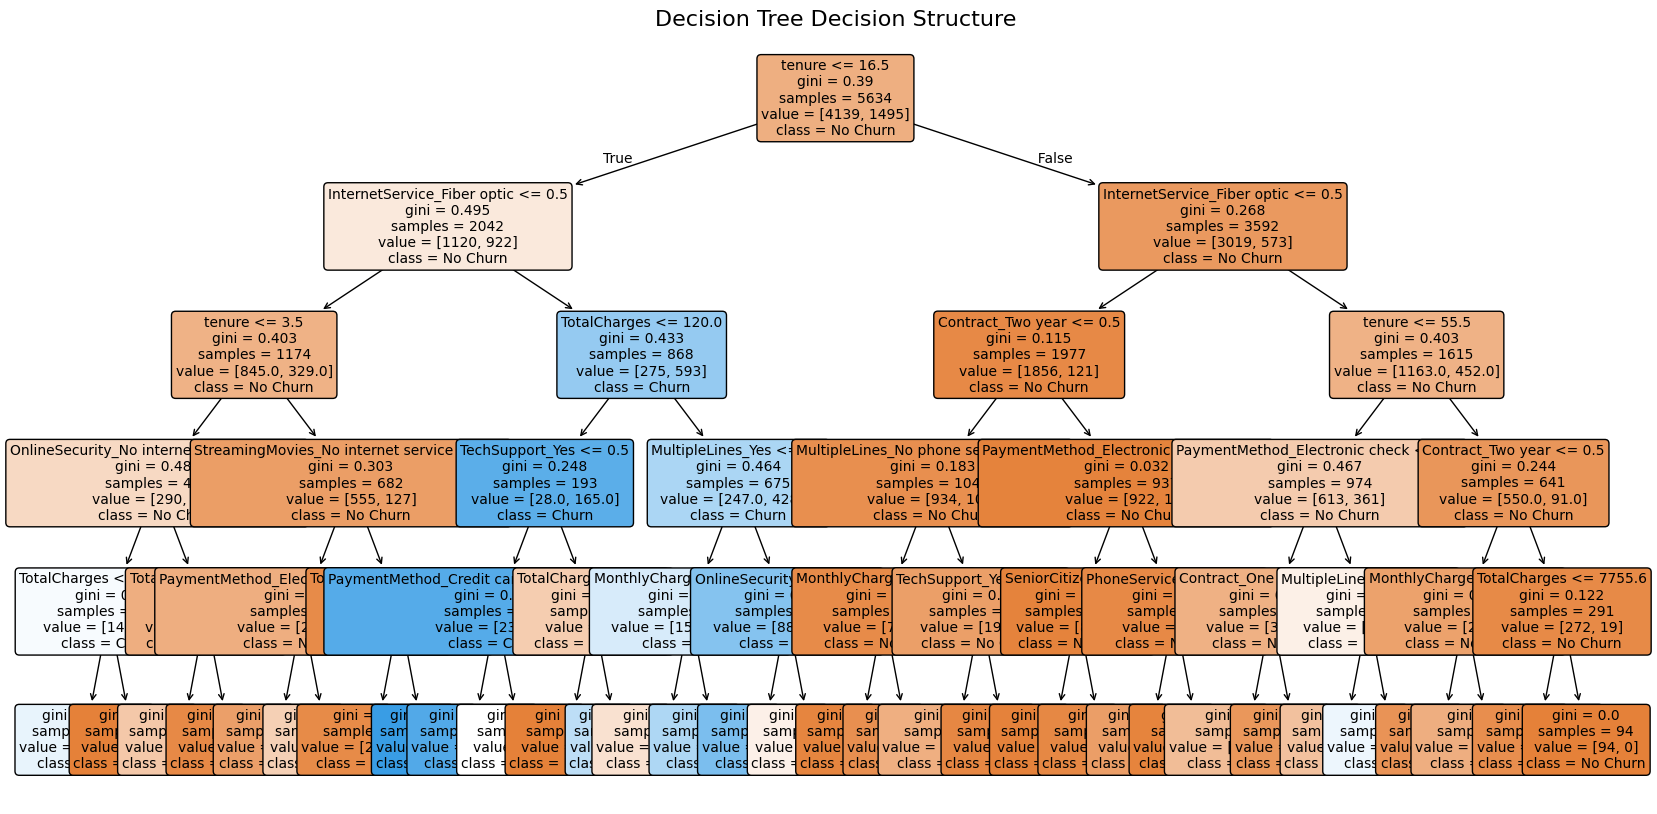

In [62]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Churn', 'Churn'],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Decision Structure", fontsize=16)
plt.show()


In [63]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [64]:
from scipy.stats import randint, uniform

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_ITER = 15  # number of random hyperparameter combinations to try per model


In [65]:
rf_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_leaf': randint(3, 15),
    'min_samples_split': randint(5, 20),
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    rf_param_dist, n_iter=N_ITER, scoring='f1', cv=cv,
    n_jobs=1, random_state=42
)
rf_search.fit(X_train_resampled, y_train_resampled)
print("Best Random Forest params:", rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.4f}")

rand_forest = evaluate_model("Random Forest", rf_search.best_estimator_,
                              X_train_resampled, y_train_resampled, X_test_scaled, y_test)


Best Random Forest params: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 191}
Best CV F1: 0.8211

===== Random Forest =====
Accuracy : 76.15%
Precision: 0.5358
Recall   : 0.7594
F1-Score : 0.6283
ROC-AUC  : 0.8425
Confusion Matrix:
 [[789 246]
 [ 90 284]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [66]:
xgb_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(2, 6),
    'learning_rate': uniform(0.01, 0.19),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 5),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_param_dist, n_iter=N_ITER, scoring='f1', cv=cv,
    n_jobs=1, random_state=42
)
xgb_search.fit(X_train_resampled, y_train_resampled)
print("Best XGBoost params:", xgb_search.best_params_)
print(f"Best CV F1: {xgb_search.best_score_:.4f}")

xgb_model = evaluate_model("XGBoost", xgb_search.best_estimator_,
                            X_train_resampled, y_train_resampled, X_test_scaled, y_test)


Best XGBoost params: {'gamma': np.float64(0.15656646227779292), 'learning_rate': np.float64(0.17003410717304973), 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 289}
Best CV F1: 0.8530

===== XGBoost =====
Accuracy : 77.50%
Precision: 0.5733
Recall   : 0.5963
F1-Score : 0.5845
ROC-AUC  : 0.8260
Confusion Matrix:
 [[869 166]
 [151 223]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.60      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [67]:
lgbm_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [3, 4, 5, 6],
    'learning_rate': uniform(0.01, 0.19),
    'min_child_samples': randint(15, 60),
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    lgbm_param_dist, n_iter=N_ITER, scoring='f1', cv=cv,
    n_jobs=1, random_state=42
)
lgbm_search.fit(X_train_resampled, y_train_resampled)
print("Best LightGBM params:", lgbm_search.best_params_)
print(f"Best CV F1: {lgbm_search.best_score_:.4f}")

lgbm_model = evaluate_model("LightGBM", lgbm_search.best_estimator_,
                             X_train_resampled, y_train_resampled, X_test_scaled, y_test)


Best LightGBM params: {'learning_rate': np.float64(0.07340463611641415), 'max_depth': 6, 'min_child_samples': 38, 'n_estimators': 230}
Best CV F1: 0.8558

===== LightGBM =====
Accuracy : 78.00%
Precision: 0.5800
Recall   : 0.6203
F1-Score : 0.5995
ROC-AUC  : 0.8279
Confusion Matrix:
 [[867 168]
 [142 232]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.58      0.62      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.79      0.78      0.78      1409



In [68]:
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
display(results_df.drop(columns='y_proba'))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.761533,0.535849,0.759358,0.628319,0.842499
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841585
4,LightGBM,0.779986,0.580000,0.620321,0.599483,0.827924
3,XGBoost,0.775018,0.573265,0.596257,0.584535,0.826012
1,Decision Tree,0.794180,0.629630,0.545455,0.584527,0.828358


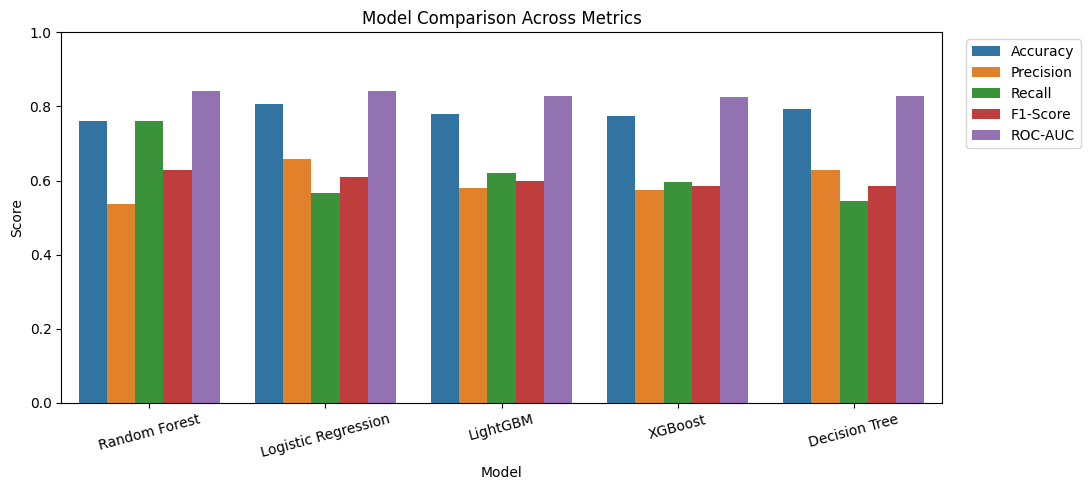

In [69]:
# Visual comparison across models
plot_df = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                           var_name='Metric', value_name='Score')

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.title("Model Comparison Across Metrics")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [70]:
base_estimators = [
    ('Random Forest', rf_search.best_estimator_),
    ('XGBoost', xgb_search.best_estimator_),
    ('LightGBM', lgbm_search.best_estimator_),
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking_model = evaluate_model("Stacking Classifier", stacking_model,
                                 X_train_resampled, y_train_resampled, X_test_scaled, y_test)



===== Stacking Classifier =====
Accuracy : 77.93%
Precision: 0.5734
Recall   : 0.6578
F1-Score : 0.6127
ROC-AUC  : 0.8357
Confusion Matrix:
 [[852 183]
 [128 246]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [71]:
final_results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
display(final_results_df.drop(columns='y_proba'))

best_model_name = final_results_df.iloc[0]["Model"]
print(f"\nBest performing model: {best_model_name}")


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.761533,0.535849,0.759358,0.628319,0.842499
5,Stacking Classifier,0.779276,0.573427,0.657754,0.612702,0.835717
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841585
4,LightGBM,0.779986,0.580000,0.620321,0.599483,0.827924
3,XGBoost,0.775018,0.573265,0.596257,0.584535,0.826012
1,Decision Tree,0.794180,0.629630,0.545455,0.584527,0.828358



Best performing model: Random Forest


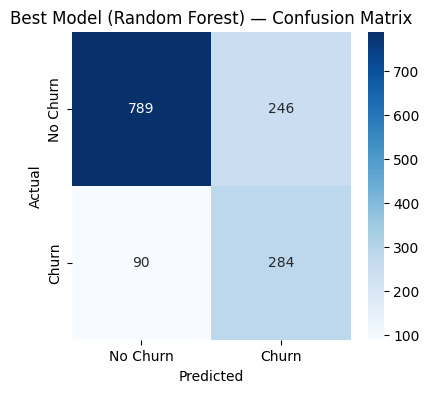

In [72]:
fitted_model_lookup = {
    "Random Forest": rand_forest,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "Stacking Classifier": stacking_model,
    "Logistic Regression": log_reg,
    "Decision Tree": dt_model,
}
best_model_object = fitted_model_lookup[best_model_name]

# Confusion matrix for the winning model
best_X_test = X_test if best_model_name == "Decision Tree" else X_test_scaled
y_pred_best = best_model_object.predict(best_X_test)
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title(f'Best Model ({best_model_name}) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [73]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
save_path = "/content/drive/MyDrive/best_churn_model.pkl"

artifact = {
    "model": best_model_object,
    "scaler": scaler,
    "feature_columns": list(X.columns),
    "model_name": best_model_name,
}

pickle.dump(artifact, open(save_path, 'wb'))
loaded = pickle.load(open(save_path, 'rb'))
print(f"Model + preprocessing artifact saved to: {save_path}")


Model + preprocessing artifact saved to: /content/drive/MyDrive/best_churn_model.pkl


In [75]:
loaded_model = loaded["model"]

test_pred = loaded_model.predict(X_test_scaled if loaded["model_name"] != "Decision Tree" else X_test)
print("Reloaded model accuracy check:", accuracy_score(y_test, test_pred))


Reloaded model accuracy check: 0.7615330021291696
